# Per-Format Validation Analysis

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cbook import boxplot_stats
import subprocess, warnings, os
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)


In [2]:
# Publication settings
width = 3.487
height = width / 1.618
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams.update({'font.size': 7})

palette = ['#4daf4a','#e41a1c','#984ea3','#377eb8','#ff7f00']
ranges_dev = ['NVIDIA-H100', 'AMD-MI250', 'AMD-EPYC-64', 'INTEL-SAPPHIRE-56', 'ARM-GRACE-72']
color_dictionary = dict(zip(ranges_dev, palette))

def change_colors(devs, cdict):
    sns.set_palette([v for k,v in cdict.items() if k in devs])

change_colors(ranges_dev, color_dictionary)


In [3]:
# Format name mapping (from benchmark_aggregation.ipynb)
format_name_mapping = {
    'cuSPARSE_csr11': 'cu-CSR', 'cuSPARSE_coo11': 'cu-COO', 'cuSPARSE_hyb9-2': 'cu-HYB',
    'CUSPARSE_CSR': 'cu-CSR', 'CUSPARSE_COO': 'cu-COO',
    'ROCSPARSE_CSR': 'roc-CSR', 'ROCSPARSE_COO': 'roc-COO', 'ROCSPARSE_HYB': 'roc-HYB',
    'Merge_11': 'Merge-CSR', 'MERGE_CUDA': 'Merge-CSR', 'MERGE': 'Merge-CSR',
    'Custom_CSR_CUDA_ADAPTIVE_b512_1': 'Ada-CSR', 'Custom_CSR_CUDA_ADAPTIVE_b256_1': 'Ada-CSR',
    'Custom_CSR_ROCM_ADAPTIVE_b512_1': 'Ada-CSR',
    'Custom_CSR_CUDA_VECTOR_b256': 'Vec-CSR', 'Custom_CSR_ROCM_VECTOR_b512': 'Vec-CSR',
    'Custom_CSR_CUDA_constant_nnz_per_thread_b1024_nnz4': 'Custom-CSR',
    'Custom_CSR_ROCM_constant_nnz_per_thread_b512_nnz4': 'Custom-CSR',
    'ACC_LINE_ENHANCE_b512': 'ACC-Line', 'ACC_FLAT_b512': 'ACC-Flat',
    'SELL-32-1': 'SELL-C-σ', 'Naive_CSR_CPU': 'Naive-CSR',
    'Custom_CSR_B': 'Bal-CSR', 'Custom_CSR_BV_x86': 'Vec-CSR', 'Custom_CSR_BV_SVE': 'Vec-CSR',
    'Custom_CSR_PBV': 'Custom_CSR_BV',
    'MKL_IE': 'MKL-IE', 'AOCL_OPTMV': 'AOCL', 'ARMPL': 'ARM-lib',
    'SparseX': 'SparseX', 'CSR5_9': 'CSR5', 'CSR5_CUDA': 'CSR5', 'CSR5': 'CSR5',
    'DASP_CUDA': 'DASP', 'LCM': 'LCM',
}


In [4]:
# Load data
df_real_all = pd.read_csv('validation_real_benchmarks_all-devices_all.csv')
df_friends_all = pd.read_csv('validation_friends_benchmarks_all-devices_all.csv')
print(f'Real: {df_real_all.shape}, Friends: {df_friends_all.shape}')

# Apply format mapping to real data
df_real_all['format_name'] = df_real_all['format_name'].replace(format_name_mapping)

# Filter devices & exclude matrices
exclude_matrices = ['mawi_201512012345', 'kmer_V2a']
df_real_all = df_real_all[df_real_all['System'].isin(ranges_dev) & ~df_real_all['matrix_name'].isin(exclude_matrices)]
df_friends_all = df_friends_all[df_friends_all['System'].isin(ranges_dev)]

# Dedup: if multiple raw names map to same short name for same (matrix, device, format), keep best
df_real_all = df_real_all.loc[df_real_all.groupby(['matrix_name','System','format_name'])['gflops'].idxmax()].reset_index(drop=True)
print(f'After filter+dedup => Real: {df_real_all.shape}, Friends: {df_friends_all.shape}')
print(f'Unique real matrices: {df_real_all["matrix_name"].nunique()}')


Real: (4228, 32), Friends: (268041, 30)
After filter+dedup => Real: (2048, 32), Friends: (137210, 30)
Unique real matrices: 50


In [5]:
# Feature matching (reused from validation.ipynb)
llc_threshold = {'AMD-EPYC-64': 256, 'INTEL-SAPPHIRE-56': 105, 'ARM-GRACE-72': 114}
FEATURES = ['nr_rows', 'avg_nnz_per_row', 'skew', 'cross_row_similarity', 'avg_num_neighbours']

def get_em_feats(pcg, features, dataframe, row, threshold=1):
    low, high = 1 - pcg*0.01, 1 + pcg*0.01
    feature_boolean = pd.Series(True, index=dataframe.index)
    for i, feature in enumerate(features):
        fb_tmp = feature_boolean & (dataframe[feature] <= row[feature]*high) & (dataframe[feature] >= row[feature]*low)
        isol = dataframe[fb_tmp]
        skew_threshold = 5
        if feature == 'skew' and row[feature] < skew_threshold:
            fb_tmp = feature_boolean & (dataframe[feature] <= row[feature]+skew_threshold) & (dataframe[feature] >= row[feature]-skew_threshold)
            isol = dataframe[fb_tmp]
        pcg2_limit, pcg2 = 45, pcg
        if feature in ('avg_num_neighbours', 'cross_row_similarity'):
            while isol.shape[0] < threshold:
                pcg2 += 1
                if pcg2 > pcg2_limit: break
                low2, high2 = 1-pcg2*0.01, 1+pcg2*0.01
                fb_tmp = feature_boolean & (dataframe[feature] <= row[feature]*high2) & (dataframe[feature] >= row[feature]*low2)
                isol = dataframe[fb_tmp]
            reg_threshold = 0.04
            if row[feature] < 0.1 and isol.shape[0] < threshold:
                fb_tmp = feature_boolean & (dataframe[feature] <= row[feature]+reg_threshold) & (dataframe[feature] >= row[feature]-reg_threshold)
                isol = dataframe[fb_tmp]
        feature_boolean = fb_tmp
    return dataframe[feature_boolean]

def find_friends_for_matrix(row, friends_device, system, threshold=10):
    """Find feature-matched friends, with LLC filtering for CPUs."""
    # Deduplicate friends for feature matching (one row per unique friend matrix)
    dedup_cols = ['nr_rows','nr_cols','nr_nzeros','avg_nnz_per_row','skew','avg_num_neighbours','cross_row_similarity']
    friends_dedup = friends_device.drop_duplicates(subset=dedup_cols)
    matched_dedup = get_em_feats(30, FEATURES, friends_dedup, row, threshold)
    # LLC filtering for CPUs
    if system in llc_threshold:
        total_mf = row['mem_footprint'] + row['nr_rows']*8/(1024*1024.0) + row['nr_cols']*8/(1024*1024.0)
        if total_mf < llc_threshold[system]:
            matched_dedup = matched_dedup[matched_dedup['mem_footprint'] < llc_threshold[system]]
        else:
            matched_dedup = matched_dedup[matched_dedup['mem_footprint'] > llc_threshold[system]]
    # Join back to get all format rows for matched friends
    matched_keys = matched_dedup[dedup_cols]
    matched_friends = friends_device.merge(matched_keys, on=dedup_cols, how='inner')
    return matched_friends


---
# Per-Format Error Computation

In [6]:
def compute_per_format_errors(ranges_dev, df_real_all, df_friends_all):
    """Core analysis: compute per-(device, matrix, format) errors."""
    all_results = []
    for system in ranges_dev:
        print(f'\n=== {system} ===')
        real_dev = df_real_all[df_real_all['System'] == system].sort_values('mem_footprint')
        friends_dev = df_friends_all[df_friends_all['System'] == system]
        real_matrices = real_dev['matrix_name'].unique()
        for mtx in real_matrices:
            real_mtx = real_dev[real_dev['matrix_name'] == mtx]
            row_ref = real_mtx.iloc[0]  # features are same across formats
            matched_friends = find_friends_for_matrix(row_ref, friends_dev, system)
            n_unique_friends = matched_friends.drop_duplicates(
                subset=['nr_rows','nr_cols','nr_nzeros']).shape[0]
            # Per format
            real_formats = set(real_mtx['format_name'])
            friend_formats = set(matched_friends['format_name'])
            common_formats = real_formats & friend_formats
            for fmt in common_formats:
                real_gflops = real_mtx[real_mtx['format_name']==fmt]['gflops'].values[0]
                friend_gflops = matched_friends[matched_friends['format_name']==fmt]['gflops'].values
                if real_gflops <= 0 or len(friend_gflops) == 0:
                    continue
                apes = np.abs(friend_gflops - real_gflops) / real_gflops * 100
                mape = np.mean(apes)
                std_gflops = np.std(friend_gflops)
                mean_gflops = np.mean(friend_gflops)
                cv = (std_gflops / mean_gflops * 100) if mean_gflops > 0 else 0
                median_gflops = np.median(friend_gflops)
                all_results.append({
                    'System': system, 'matrix_name': mtx, 'format_name': fmt,
                    'real_gflops': real_gflops, 'n_friends': len(friend_gflops),
                    'n_unique_friends': n_unique_friends,
                    'friend_mean': mean_gflops, 'friend_median': median_gflops,
                    'friend_std': std_gflops, 'MAPE': mape, 'CV': cv,
                    'mem_footprint': row_ref['mem_footprint'],
                })
        print(f'  {len(real_matrices)} matrices processed')
    return pd.DataFrame(all_results)


In [7]:
results_df = compute_per_format_errors(ranges_dev, df_real_all, df_friends_all)
print(f'\nTotal results: {results_df.shape}')
results_df.head(10)



=== NVIDIA-H100 ===
  50 matrices processed

=== AMD-MI250 ===
  50 matrices processed

=== AMD-EPYC-64 ===
  50 matrices processed

=== INTEL-SAPPHIRE-56 ===
  50 matrices processed

=== ARM-GRACE-72 ===
  50 matrices processed

Total results: (1988, 12)


,System,matrix_name,format_name,real_gflops,n_friends,n_unique_friends,friend_mean,friend_median,friend_std,MAPE,CV,mem_footprint
0,NVIDIA-H100,scircuit,cu-COO,128.97400,63,40,124.778542,124.675644,8.100755,5.301202,6.492106,11.6265
1,NVIDIA-H100,scircuit,Ada-CSR,142.52860,63,40,142.471682,142.232963,8.399147,3.420354,5.895310,11.6265
2,NVIDIA-H100,scircuit,Vec-CSR,49.07304,63,40,49.202914,49.131677,3.737756,3.596372,7.596616,11.6265
3,NVIDIA-H100,scircuit,Custom-CSR,115.23620,63,40,106.794441,108.290382,6.335651,7.547756,5.932566,11.6265
4,NVIDIA-H100,scircuit,Merge-CSR,85.42026,63,40,82.629592,83.256994,5.176717,4.314825,6.264967,11.6265
5,NVIDIA-H100,scircuit,CSR5,113.37260,63,40,111.030771,110.566704,9.113691,5.689742,8.208257,11.6265
6,NVIDIA-H100,scircuit,cu-CSR,132.62740,63,40,128.125110,127.853616,8.860462,5.552077,6.915476,11.6265
7,NVIDIA-H100,scircuit,DASP,43.73800,63,40,42.667532,41.850528,3.866001,6.985362,9.060756,11.6265
8,NVIDIA-H100,mac_econ_fwd500,cu-COO,151.58060,66,37,152.316009,151.471658,10.818138,3.686642,7.102430,15.3605
9,NVIDIA-H100,mac_econ_fwd500,Ada-CSR,146.06800,37,37,173.899959,174.315248,12.421208,19.297902,7.142732,15.3605


---
# Summary Tables

In [8]:
# Table 1: Per-device, per-format MAPE + StdDev + CV
fmt_summary = results_df.groupby(['System','format_name']).agg(
    MAPE_mean=('MAPE','mean'), MAPE_std=('MAPE','std'),
    StdDev_mean=('friend_std','mean'), CV_mean=('CV','mean'),
    n_matrices=('matrix_name','nunique'), n_friends_mean=('n_friends','mean')
).reset_index()
fmt_summary = fmt_summary.round(2)

for dev in ranges_dev:
    print(f'\n=== {dev} ===')
    dev_df = fmt_summary[fmt_summary['System']==dev].sort_values('MAPE_mean')
    print(dev_df.to_string(index=False))



=== NVIDIA-H100 ===
     System format_name  MAPE_mean  MAPE_std  StdDev_mean  CV_mean  n_matrices  n_friends_mean
NVIDIA-H100   Merge-CSR       5.65      3.83         9.17     4.39          50           62.62
NVIDIA-H100      cu-COO       5.86      4.85         8.10     3.23          50           62.68
NVIDIA-H100        CSR5       7.91      6.05        12.46     5.14          50           62.68
NVIDIA-H100      cu-CSR       8.33     19.04        10.90     3.74          50           62.68
NVIDIA-H100     Vec-CSR       8.44      7.60         9.21     6.27          50           62.68
NVIDIA-H100     Ada-CSR       9.29      8.46         5.86     3.16          45           51.91
NVIDIA-H100        DASP      15.21     12.84        16.13     6.66          50           62.68
NVIDIA-H100  Custom-CSR      19.78     55.07         8.24     3.65          50           62.68

=== AMD-MI250 ===
   System format_name  MAPE_mean  MAPE_std  StdDev_mean  CV_mean  n_matrices  n_friends_mean
AMD-MI250   

In [9]:
# Table 2: Per-device condensed summary (what replaces old Table 4)
dev_summary = results_df.groupby('System').agg(
    MAPE=('MAPE','mean'), MAPE_std=('MAPE','std'),
    Mean_StdDev=('friend_std','mean'), Mean_CV=('CV','mean'),
    n_format_matrix_pairs=('matrix_name','count')
).reindex(ranges_dev).reset_index()
dev_summary.loc[len(dev_summary)] = ['Average'] + list(dev_summary.iloc[:,1:].mean())
dev_summary = dev_summary.round(2)
print('\n=== Per-Device Summary (replaces Table 4) ===')
print(dev_summary.to_string(index=False))



=== Per-Device Summary (replaces Table 4) ===
           System  MAPE  MAPE_std  Mean_StdDev  Mean_CV  n_format_matrix_pairs
      NVIDIA-H100 10.07     22.11        10.06     4.55                  395.0
        AMD-MI250 21.75     33.67         4.04     7.36                  400.0
      AMD-EPYC-64 31.16     96.03         4.40     7.59                  477.0
INTEL-SAPPHIRE-56 20.69     21.80         5.42     8.11                  418.0
     ARM-GRACE-72 20.23     19.57         7.77     8.02                  298.0
          Average 20.78     38.64         6.34     7.13                  397.6


In [10]:
# Export CSVs
fmt_summary.to_csv('validation_per_format_detailed.csv', index=False)
dev_summary.to_csv('validation_per_device_summary.csv', index=False)
print('Saved: validation_per_format_detailed.csv, validation_per_device_summary.csv')


Saved: validation_per_format_detailed.csv, validation_per_device_summary.csv


---
# Per-Device Matrix × Format Error Tables
# Rows = matrices (sorted by mem_footprint), Columns = formats, Cells = MAPE (%)

In [11]:
# Build and display one pivot table per device
top_avg_all_devices = []
top_single_all_devices = []

for dev in ranges_dev:
    dev_results = results_df[results_df['System'] == dev].copy()
    if dev_results.empty:
        continue
    # Sort matrices by mem_footprint
    mtx_order = dev_results.drop_duplicates('matrix_name').sort_values('mem_footprint')['matrix_name'].values
    pivot = dev_results.pivot_table(index='matrix_name', columns='format_name', values='MAPE', aggfunc='mean')
    pivot = pivot.reindex(mtx_order)
    # Add a row-average column and a column-average row
    pivot['ROW_AVG'] = pivot.mean(axis=1)
    col_avg = pivot.mean(axis=0)
    col_avg.name = 'COL_AVG'
    pivot = pd.concat([pivot, col_avg.to_frame().T])
    pivot = pivot.round(1)
    print(f'\n{"="*80}')
    print(f'  {dev} — MAPE (%) per Matrix × Format')
    print(f'{"="*80}')
    print(pivot.to_string())
    # Export
    csv_name = f'validation_matrix_format_MAPE_{dev}.csv'
    pivot.to_csv(csv_name)
    print(f'  -> Saved to {csv_name}')

    # Top 10 matrices with highest average errors
    top_avg = pivot['ROW_AVG'].drop('COL_AVG', errors='ignore').sort_values(ascending=False).head(10)
    print(f'\n  [Top 10 Matrices with Highest Average Error]')
    print(top_avg.to_string())

    df_avg = pd.DataFrame({
        f'{dev}_Matrix': top_avg.index,
        f'{dev}_Error(%)': top_avg.values.round(1)
    }).reset_index(drop=True)
    top_avg_all_devices.append(df_avg)
    
    # Top 10 matrices with highest single format errors
    top_single = dev_results.sort_values(by='MAPE', ascending=False).head(10)
    print(f'\n  [Top 10 Highest Single-Format Errors]')
    print(top_single[['matrix_name', 'format_name', 'MAPE']].to_string(index=False))

    df_single = pd.DataFrame({
        f'{dev}_Matrix(Format)': top_single['matrix_name'] + ' (' + top_single['format_name'] + ')',
        f'{dev}_Error(%)': top_single['MAPE'].values.round(1)
    }).reset_index(drop=True)
    top_single_all_devices.append(df_single)


  NVIDIA-H100 — MAPE (%) per Matrix × Format
format_name         Ada-CSR  CSR5  Custom-CSR  DASP  Merge-CSR  Vec-CSR  cu-COO  cu-CSR  ROW_AVG
scircuit                3.4   5.7         7.5   7.0        4.3      3.6     5.3     5.6      5.3
mac_econ_fwd500        19.3   5.6         5.3  22.5        5.9      3.5     3.7     5.8      9.0
raefsky3                2.9  10.6         4.4   8.4        4.6      4.2     5.5     4.1      5.6
rgg_n_2_17_s0          17.6  10.5         9.3  10.8       11.5      5.8     6.6     9.4     10.2
bbmat                   9.0  11.6         9.4   5.2       12.1     10.7     9.7     8.9      9.6
appu                   10.4   6.5         3.9   6.8        3.2      4.1     2.2     3.3      5.1
mc2depi                 9.5   8.4         5.7  11.3        5.1      4.7     8.0     7.8      7.6
rma10                   4.9  15.2         8.1  19.9       10.8      8.0     8.7     8.8     10.6
cop20k_A               46.0   4.2         2.6  29.3        3.2      5.3     2.9  

In [12]:
# Combine and export top 10 errors across all devices
df_top_avg_all = pd.concat(top_avg_all_devices, axis=1)
df_top_avg_all.to_csv('validation_top10_avg_error_all_devices.csv', index=False)
print('\nSaved: validation_top10_avg_error_all_devices.csv')

df_top_single_all = pd.concat(top_single_all_devices, axis=1)
df_top_single_all.to_csv('validation_top10_single_format_error_all_devices.csv', index=False)
print('Saved: validation_top10_single_format_error_all_devices.csv')



Saved: validation_top10_avg_error_all_devices.csv
Saved: validation_top10_single_format_error_all_devices.csv


---
# Plotting: Stacked All-Devices (best-of format, like original Figure 1)


In [13]:
def get_best_format_data(df_real_all, system):
    """Get best-format row per matrix for a device (for the boxplot figure)."""
    real_dev = df_real_all[df_real_all['System']==system].sort_values('mem_footprint')
    best_rows = real_dev.loc[real_dev.groupby('matrix_name')['gflops'].idxmax()]
    return best_rows.sort_values('mem_footprint')

def plot_stacked_validation(ranges_dev, df_real_all, df_friends_all):
    """Stacked boxplot: one subplot per device, best-of format."""
    font = 7
    fig, axs = plt.subplots(len(ranges_dev))
    fig.subplots_adjust(left=.12, bottom=.17*(2/5)*(4/3.5), right=.99, top=.94)
    validation_meta_all = []
    for ctr, system in enumerate(ranges_dev):
        change_colors([system], color_dictionary)
        best_real = get_best_format_data(df_real_all, system)
        friends_dev = df_friends_all[df_friends_all['System']==system]
        synth_list = []
        for _, row in best_real.iterrows():
            matched = find_friends_for_matrix(row, friends_dev, system)
            # Filter to same format as best real
            fmt = row['format_name']
            matched_fmt = matched[matched['format_name']==fmt]
            if matched_fmt.empty:
                matched_fmt = matched  # fallback: use all formats of friends
                # Take best-of per friend
                dedup_cols = ['nr_rows','nr_cols','nr_nzeros']
                keys = matched_fmt.drop_duplicates(subset=dedup_cols)[dedup_cols]
                best_list = []
                for _, k in keys.iterrows():
                    mask = True
                    for c in dedup_cols:
                        mask = mask & (matched_fmt[c]==k[c])
                    friend_rows = matched_fmt[mask]
                    best_list.append(friend_rows.loc[friend_rows['gflops'].idxmax()])
                matched_fmt = pd.DataFrame(best_list)
            matched_fmt = matched_fmt.copy()
            matched_fmt['matrix_name'] = row['matrix_name']
            synth_list.append(matched_fmt)
        synth_all = pd.concat(synth_list, ignore_index=True)
        sns.boxplot(data=synth_all, x='matrix_name', y='gflops', ax=axs[ctr],
                    fliersize=0.3, linewidth=0.3, color=color_dictionary[system])
        sns.stripplot(data=best_real, x='matrix_name', y='gflops', ax=axs[ctr],
                      color='k', jitter=True, s=3, alpha=0.75, order=best_real['matrix_name'].values)
        # LLC threshold line for CPUs
        arch = best_real['Arch'].iloc[0] if 'Arch' in best_real.columns else ''
        if arch == 'CPU' and system in llc_threshold:
            xtick_items = axs[ctr].get_xticklabels()
            for item in xtick_items:
                mtx = item.get_text()
                me = best_real[best_real['matrix_name']==mtx]
                if me.empty: continue
                me = me.squeeze()
                mf = me['mem_footprint'] + me['nr_rows']*8/(1024*1024) + me['nr_cols']*8/(1024*1024)
                if mf > llc_threshold[system]:
                    pos = item.get_position()[0] - 0.5
                    axs[ctr].axvline(x=pos, color='gray', linewidth=0.25)
                    break
        axs[ctr].tick_params(axis='both', which='major', labelsize=font-2)
        axs[ctr].margins(x=0)
        axs[ctr].set_ylabel('')
        if ctr == len(ranges_dev)-1:
            xtick_labels = range(1, len(best_real)+1)
            axs[ctr].set_xlabel('Matrix ID', fontsize=font-1)
            axs[ctr].set_xticks(axs[ctr].get_xticks())
            axs[ctr].set_xticklabels(xtick_labels, fontsize=font-2, rotation=90)
        else:
            axs[ctr].set_xlabel('')
            axs[ctr].set_xticks([])
            axs[ctr].set_xticklabels([])
        axs[ctr].set_ylim([0, axs[ctr].get_ylim()[1]*1.2])
        axs[ctr].text(0.04, 0.85, system, fontsize=font-1, transform=axs[ctr].transAxes)
    fig.text(0.04, 0.5, 'GFLOPs', va='center', rotation='vertical', fontsize=font-1)
    plt.subplots_adjust(wspace=0, hspace=0)
    for ratio in [0.8, 1, 1.2]:
        fig.set_size_inches(width, 1.5*height/(2/5)*ratio*len(ranges_dev)/9)
        fname = f'./Plots/{ratio}_{len(ranges_dev)}_devices_Validation_performat_stacked.pdf'
        fig.savefig(fname, bbox_inches='tight')
        subprocess.run(['pdfcrop', fname], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        cropped = fname.replace('.pdf','-crop.pdf')
        if os.path.exists(cropped):
            subprocess.run(['mv', cropped, fname])
    plt.show()
    plt.close()


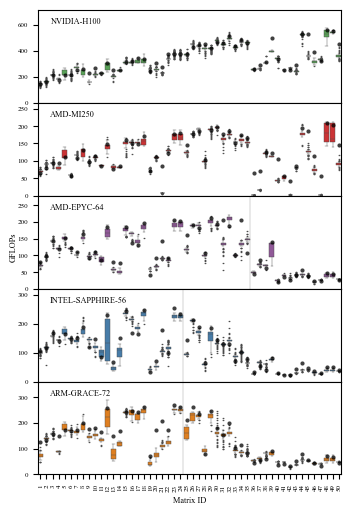

In [14]:
plot_stacked_validation(ranges_dev, df_real_all, df_friends_all)


---
# Per-Device Separate Plots (higher resolution)

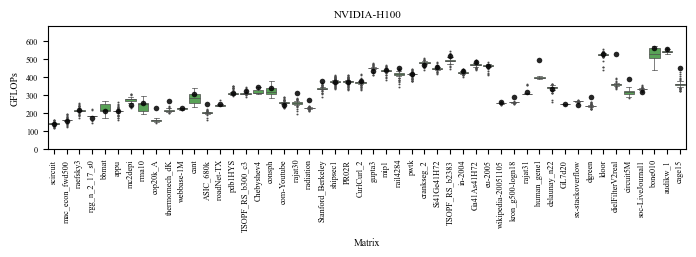

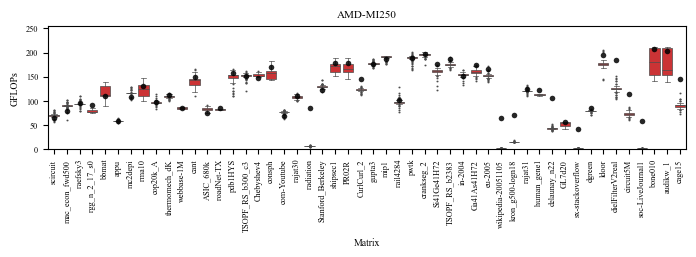

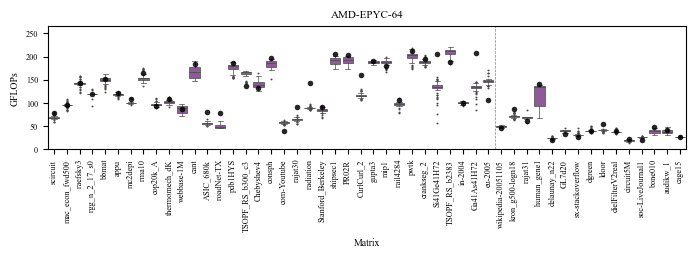

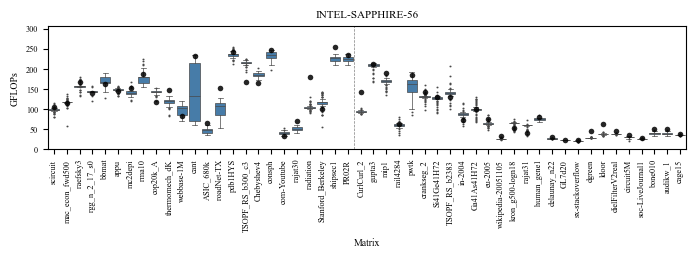

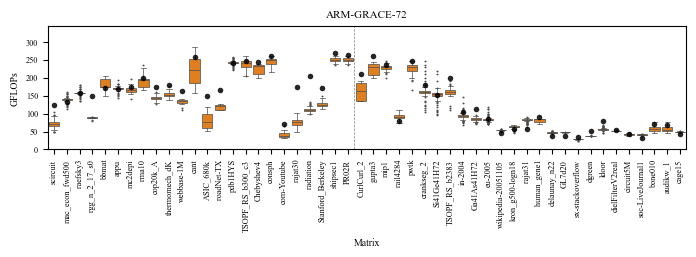

In [15]:
def plot_single_device(system, df_real_all, df_friends_all):
    """One plot per device with per-format boxplots."""
    font = 8
    change_colors([system], color_dictionary)
    best_real = get_best_format_data(df_real_all, system)
    friends_dev = df_friends_all[df_friends_all['System']==system]
    synth_list = []
    for _, row in best_real.iterrows():
        matched = find_friends_for_matrix(row, friends_dev, system)
        fmt = row['format_name']
        matched_fmt = matched[matched['format_name']==fmt]
        if matched_fmt.empty:
            dedup_cols = ['nr_rows','nr_cols','nr_nzeros']
            keys = matched.drop_duplicates(subset=dedup_cols)[dedup_cols]
            best_list = []
            for _, k in keys.iterrows():
                mask = True
                for c in dedup_cols: mask = mask & (matched[c]==k[c])
                fr = matched[mask]
                best_list.append(fr.loc[fr['gflops'].idxmax()])
            matched_fmt = pd.DataFrame(best_list)
        matched_fmt = matched_fmt.copy()
        matched_fmt['matrix_name'] = row['matrix_name']
        synth_list.append(matched_fmt)
    synth_all = pd.concat(synth_list, ignore_index=True)
    fig, ax = plt.subplots(1, 1, figsize=(width*2, height*1.2))
    sns.boxplot(data=synth_all, x='matrix_name', y='gflops', ax=ax,
                fliersize=0.5, linewidth=0.5, color=color_dictionary[system])
    sns.stripplot(data=best_real, x='matrix_name', y='gflops', ax=ax,
                  color='k', jitter=True, s=4, alpha=0.85, order=best_real['matrix_name'].values)
    # LLC line
    arch = best_real['Arch'].iloc[0] if 'Arch' in best_real.columns else ''
    if arch == 'CPU' and system in llc_threshold:
        for item in ax.get_xticklabels():
            mtx = item.get_text()
            me = best_real[best_real['matrix_name']==mtx]
            if me.empty: continue
            me = me.squeeze()
            mf = me['mem_footprint'] + me['nr_rows']*8/(1024*1024) + me['nr_cols']*8/(1024*1024)
            if mf > llc_threshold[system]:
                ax.axvline(x=item.get_position()[0]-0.5, color='gray', linewidth=0.5, linestyle='--')
                break
    ax.set_title(system, fontsize=font)
    ax.set_xlabel('Matrix', fontsize=font-1)
    ax.set_ylabel('GFLOPs', fontsize=font-1)
    ax.tick_params(axis='x', labelsize=font-2, rotation=90)
    ax.tick_params(axis='y', labelsize=font-2)
    ax.set_ylim([0, ax.get_ylim()[1]*1.15])
    plt.tight_layout()
    fname = f'./Plots/Validation_performat_{system}.pdf'
    fig.savefig(fname, bbox_inches='tight')
    subprocess.run(['pdfcrop', fname], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cropped = fname.replace('.pdf','-crop.pdf')
    if os.path.exists(cropped):
        subprocess.run(['mv', cropped, fname])
    plt.show()
    plt.close()

for dev in ranges_dev:
    plot_single_device(dev, df_real_all, df_friends_all)


---
# Per-Format, Per-Device Plots (one plot per format per device)
# Each plot title includes the aggregate stats for that (device, format) pair.

In [16]:
def plot_single_format_device(system, fmt, df_real_all, df_friends_all, results_df):
    """One plot for a specific (device, format): boxplot of friends + real dot, stats in title."""
    font = 8
    change_colors([system], color_dictionary)
    real_dev = df_real_all[(df_real_all['System']==system)].sort_values('mem_footprint')
    friends_dev = df_friends_all[df_friends_all['System']==system]

    # Only keep matrices that have this format in the real data
    real_fmt = real_dev[real_dev['format_name']==fmt].sort_values('mem_footprint')
    if real_fmt.empty:
        return
    matrix_order = real_fmt['matrix_name'].values

    # Build boxplot data: for each matrix, find feature-matched friends filtered to this format
    synth_list = []
    for _, row in real_fmt.iterrows():
        matched = find_friends_for_matrix(row, friends_dev, system)
        matched_fmt = matched[matched['format_name']==fmt].copy()
        if matched_fmt.empty:
            continue
        matched_fmt['matrix_name'] = row['matrix_name']
        synth_list.append(matched_fmt)

    if not synth_list:
        print(f'  Skipping {system} / {fmt}: no friends found for any matrix')
        return
    synth_all = pd.concat(synth_list, ignore_index=True)

    # Retrieve aggregate stats from results_df
    stats = results_df[(results_df['System']==system) & (results_df['format_name']==fmt)]
    if stats.empty:
        return
    agg_mape = stats['MAPE'].mean()
    agg_std = stats['friend_std'].mean()
    agg_cv = stats['CV'].mean()
    n_mtx = stats['matrix_name'].nunique()
    n_friends_avg = stats['n_friends'].mean()

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(width*2, height*1.2))
    # Only plot matrices that have friends
    matrices_with_friends = synth_all['matrix_name'].unique()
    plot_order = [m for m in matrix_order if m in matrices_with_friends]
    sns.boxplot(data=synth_all, x='matrix_name', y='gflops', ax=ax, order=plot_order,
                fliersize=0.5, linewidth=0.5, color=color_dictionary[system])
    # Real dots (filter to matrices with friends)
    real_plot = real_fmt[real_fmt['matrix_name'].isin(plot_order)]
    sns.stripplot(data=real_plot, x='matrix_name', y='gflops', ax=ax,
                  color='k', jitter=True, s=4, alpha=0.85, order=plot_order)

    # LLC line for CPUs
    arch = real_fmt['Arch'].iloc[0] if 'Arch' in real_fmt.columns else ''
    if arch == 'CPU' and system in llc_threshold:
        for item in ax.get_xticklabels():
            mtx = item.get_text()
            me = real_fmt[real_fmt['matrix_name']==mtx]
            if me.empty: continue
            me = me.squeeze()
            mf = me['mem_footprint'] + me['nr_rows']*8/(1024*1024) + me['nr_cols']*8/(1024*1024)
            if mf > llc_threshold[system]:
                ax.axvline(x=item.get_position()[0]-0.5, color='gray', linewidth=0.5, linestyle='--')
                break

    title_str = (f'{system}  —  {fmt}\n'
                 f'MAPE={agg_mape:.1f}%   StdDev={agg_std:.1f} GFLOPs   '
                 f'CV={agg_cv:.1f}%   #matrices={n_mtx}   '
                 f'avg #friends={n_friends_avg:.0f}')
    ax.set_title(title_str, fontsize=font-0.5)
    ax.set_xlabel('Matrix', fontsize=font-1)
    ax.set_ylabel('GFLOPs', fontsize=font-1)
    ax.tick_params(axis='x', labelsize=font-2, rotation=90)
    ax.tick_params(axis='y', labelsize=font-2)
    ax.set_ylim([0, ax.get_ylim()[1]*1.15])
    plt.tight_layout()
    fmt_safe = fmt.replace('/', '_').replace(' ', '_')
    fname = f'./Plots/Validation_{system}_{fmt_safe}.pdf'
    fig.savefig(fname, bbox_inches='tight')
    subprocess.run(['pdfcrop', fname], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cropped = fname.replace('.pdf','-crop.pdf')
    if os.path.exists(cropped):
        subprocess.run(['mv', cropped, fname])
    plt.show()
    plt.close()



=== NVIDIA-H100: 8 formats ===
  Plotting Ada-CSR...


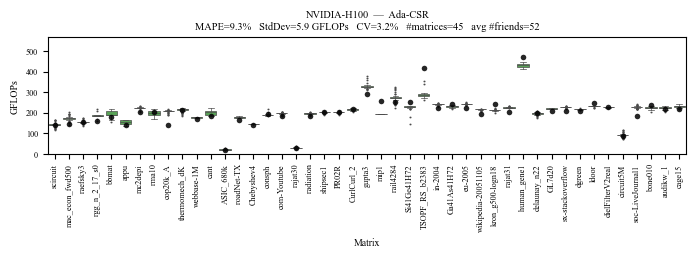

  Plotting CSR5...


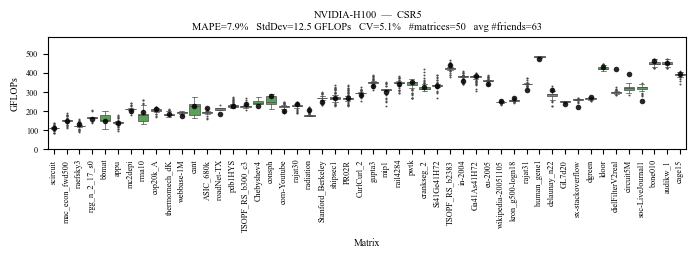

  Plotting Custom-CSR...


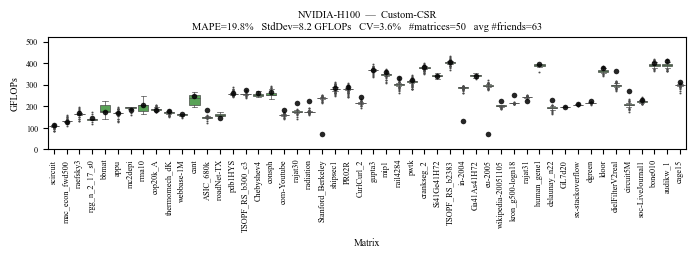

  Plotting DASP...


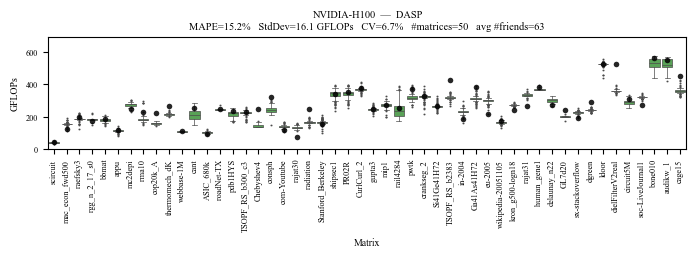

  Plotting Merge-CSR...


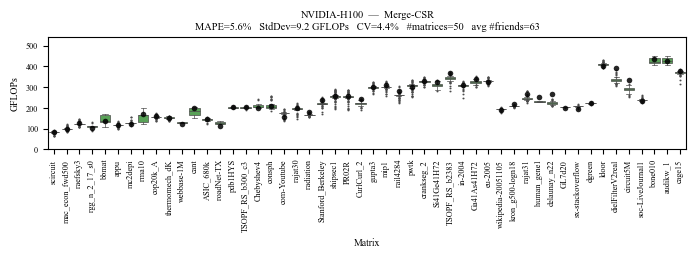

  Plotting Vec-CSR...


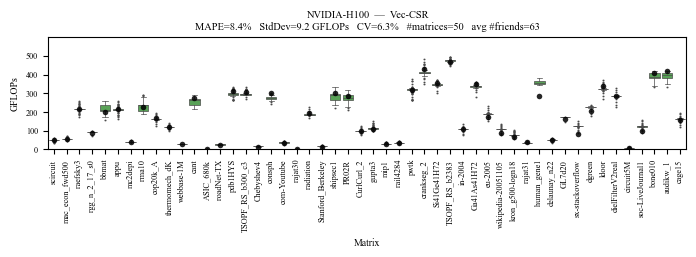

  Plotting cu-COO...


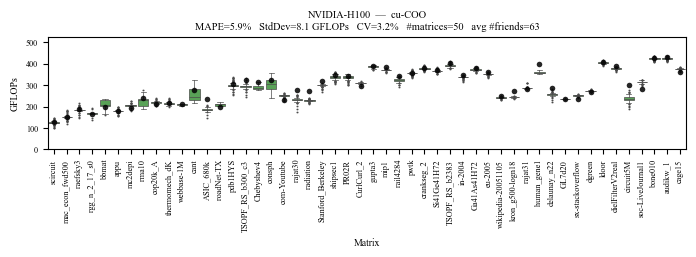

  Plotting cu-CSR...


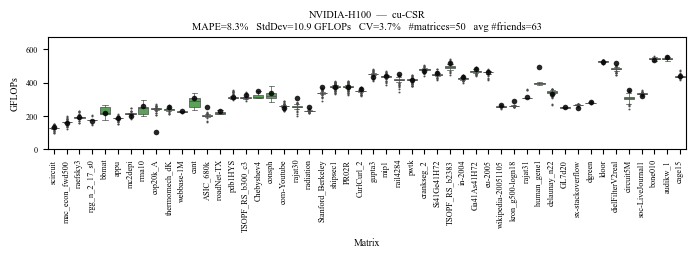


=== AMD-MI250: 8 formats ===
  Plotting ACC-Flat...


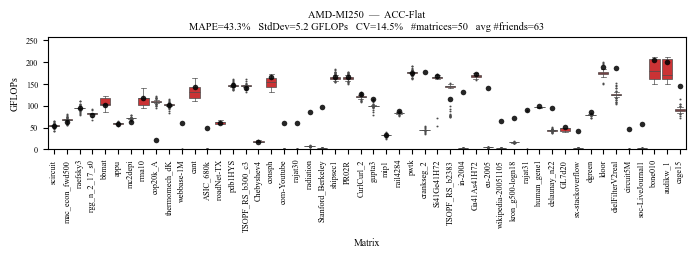

  Plotting ACC-Line...


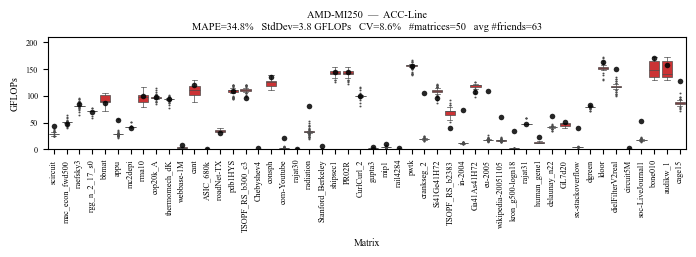

  Plotting Ada-CSR...


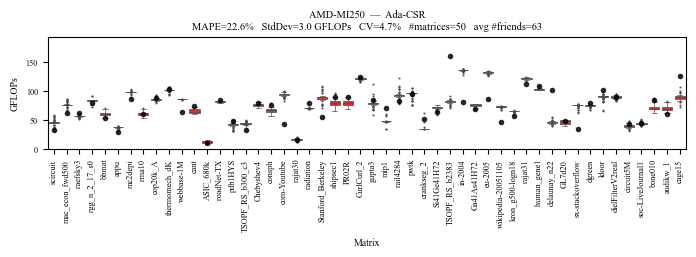

  Plotting Custom-CSR...


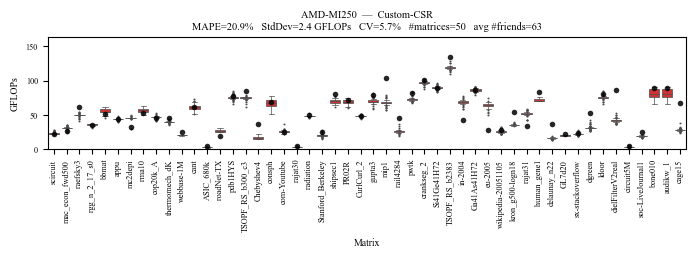

  Plotting Vec-CSR...


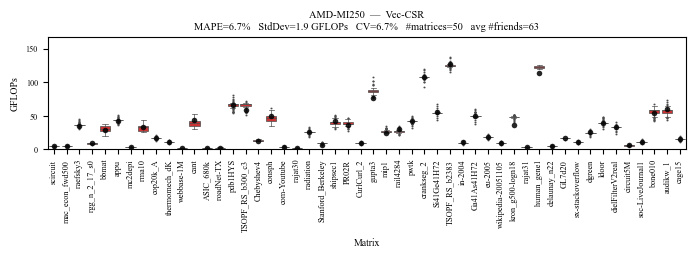

  Plotting roc-COO...


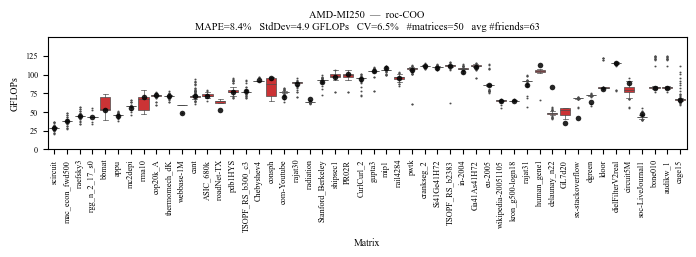

  Plotting roc-CSR...


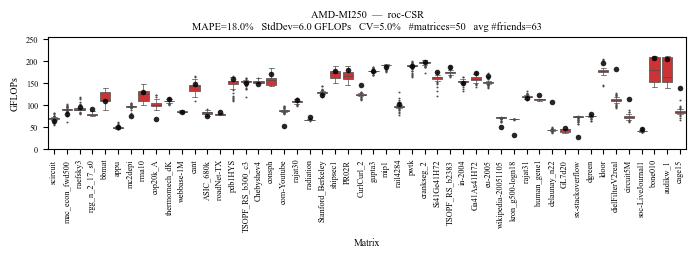

  Plotting roc-HYB...


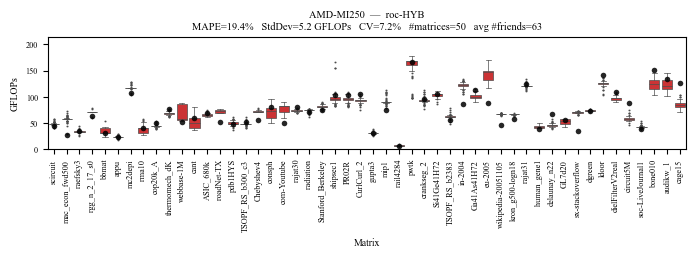


=== AMD-EPYC-64: 10 formats ===
  Plotting AOCL...


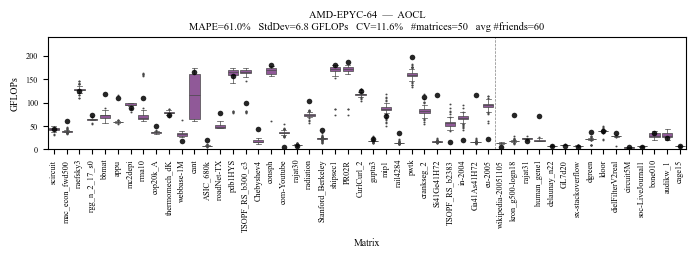

  Plotting Bal-CSR...


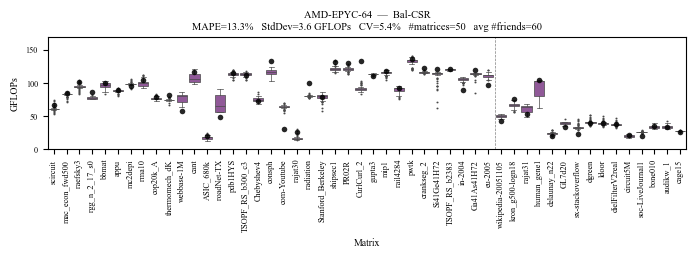

  Plotting CSR5...


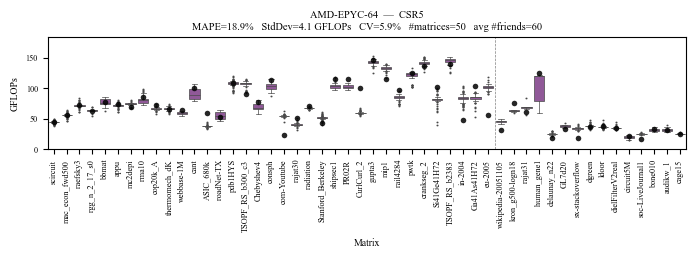

  Plotting LCM...


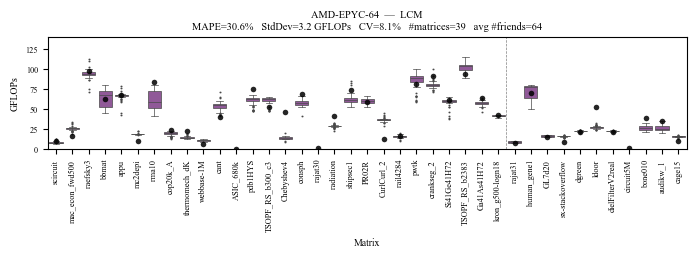

  Plotting MKL-IE...


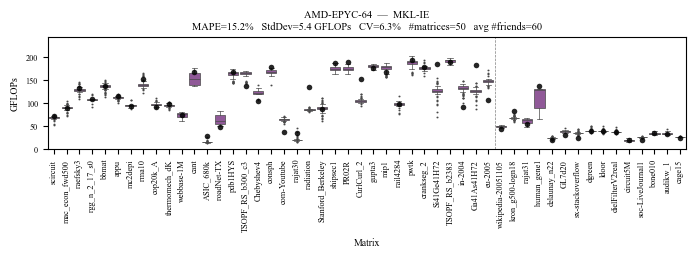

  Plotting Merge-CSR...


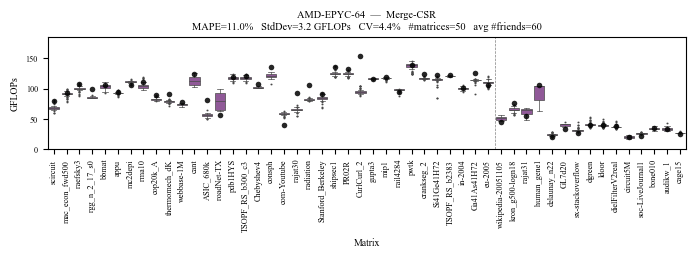

  Plotting Naive-CSR...


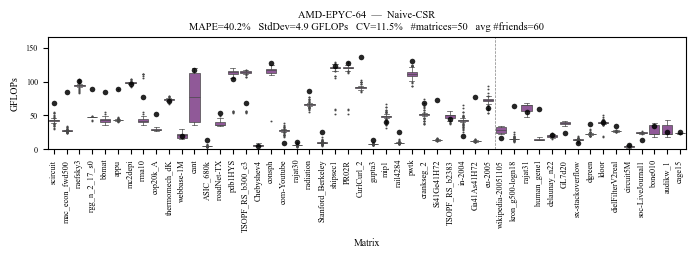

  Plotting SELL-C-σ...


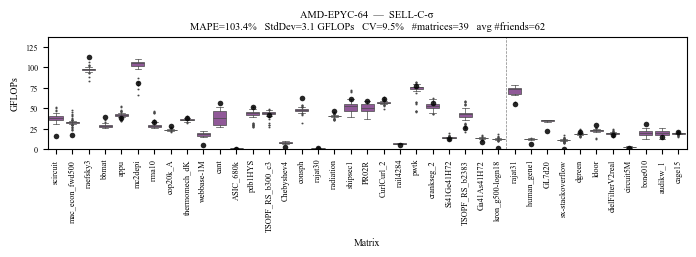

  Plotting SparseX...


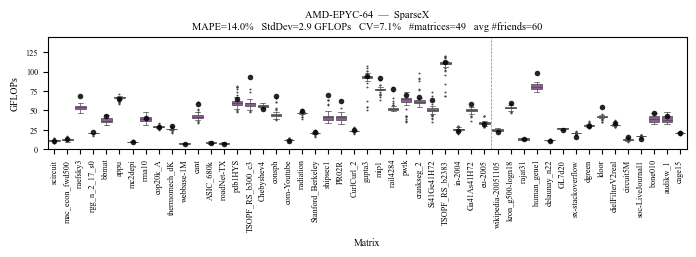

  Plotting Vec-CSR...


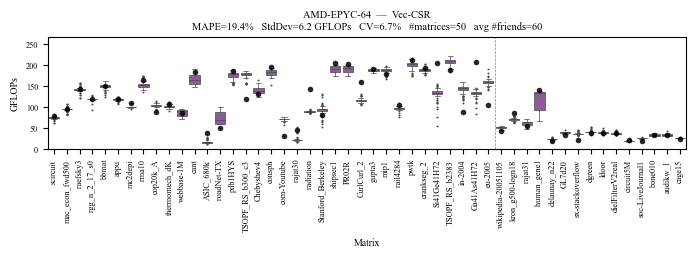


=== INTEL-SAPPHIRE-56: 9 formats ===
  Plotting Bal-CSR...


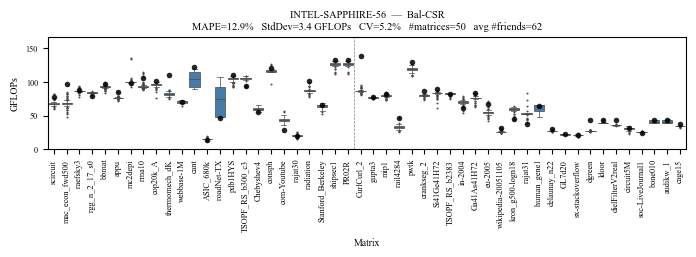

  Plotting CSR5...


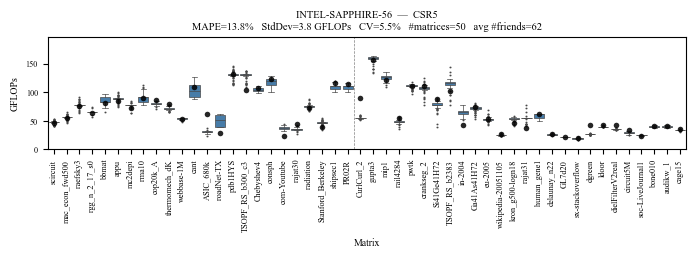

  Plotting LCM...


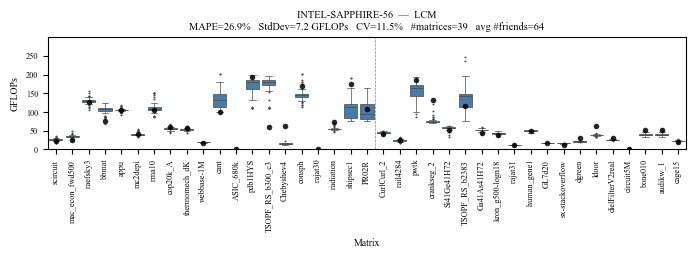

  Plotting MKL-IE...


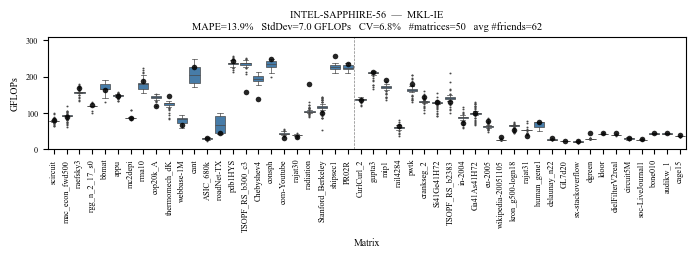

  Plotting Merge-CSR...


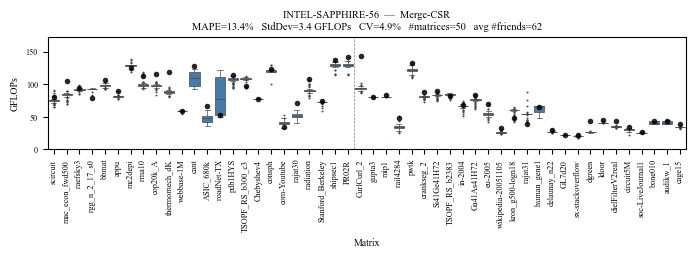

  Plotting Naive-CSR...


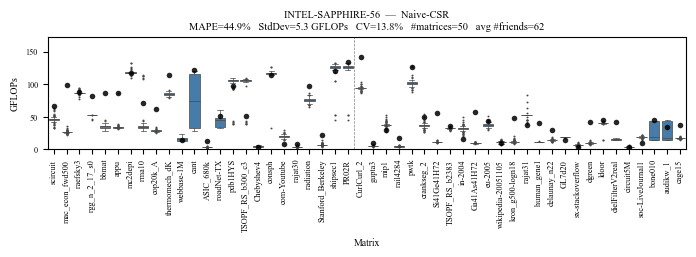

  Plotting SELL-C-σ...


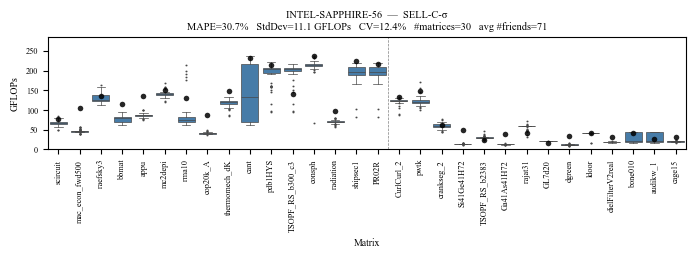

  Plotting SparseX...


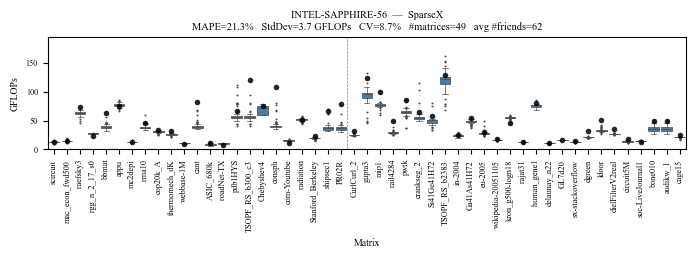

  Plotting Vec-CSR...


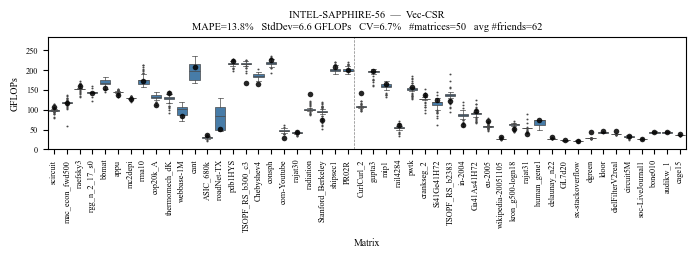


=== ARM-GRACE-72: 6 formats ===
  Plotting ARM-lib...


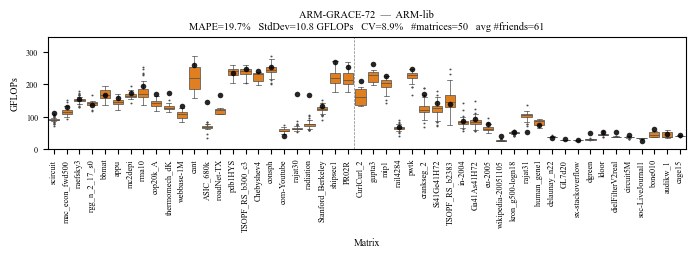

  Plotting Bal-CSR...


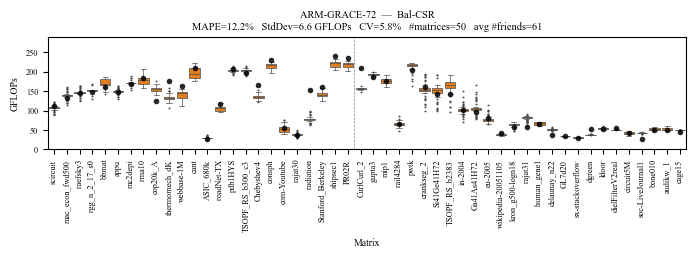

  Plotting Merge-CSR...


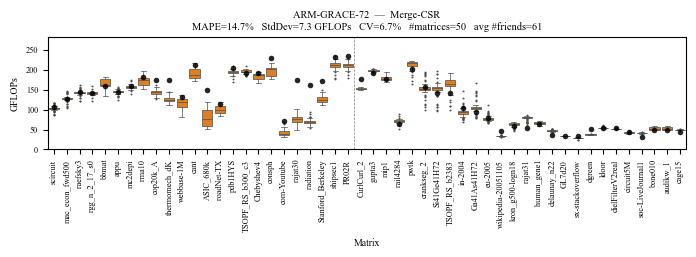

  Plotting Naive-CSR...


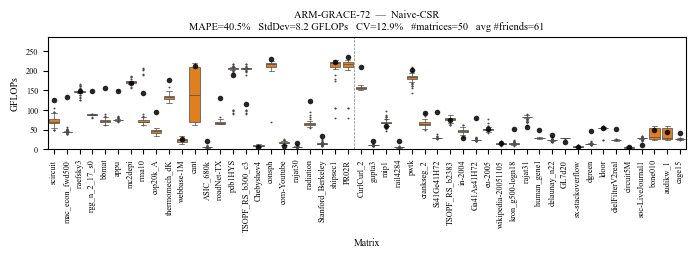

  Plotting SparseX...


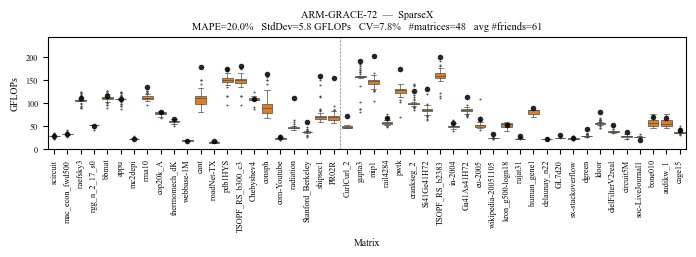

  Plotting Vec-CSR...


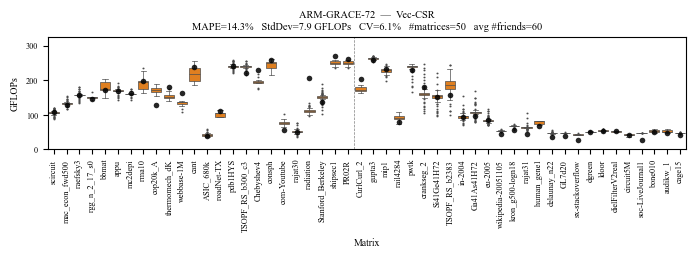

In [17]:
# Generate one plot per (device, format) combination
for dev in ranges_dev:
    dev_formats = sorted(results_df[results_df['System']==dev]['format_name'].unique())
    print(f'\n=== {dev}: {len(dev_formats)} formats ===')
    for fmt in dev_formats:
        print(f'  Plotting {fmt}...')
        plot_single_format_device(dev, fmt, df_real_all, df_friends_all, results_df)


---
# Spread Analysis: CV / StdDev Heatmap


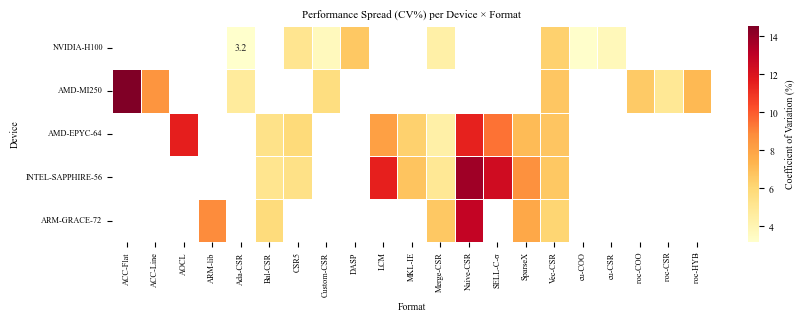

In [18]:
# Heatmap: CV per (device, format)
pivot_cv = results_df.groupby(['System','format_name'])['CV'].mean().reset_index()
pivot_cv = pivot_cv.pivot(index='System', columns='format_name', values='CV')
pivot_cv = pivot_cv.reindex(ranges_dev)

fig, ax = plt.subplots(figsize=(width*2.5, height*1.5))
sns.heatmap(pivot_cv, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Coefficient of Variation (%)'})
ax.set_title('Performance Spread (CV%) per Device × Format', fontsize=8)
ax.set_xlabel('Format', fontsize=7)
ax.set_ylabel('Device', fontsize=7)
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig('./Plots/Validation_CV_heatmap.pdf', bbox_inches='tight')
plt.show()


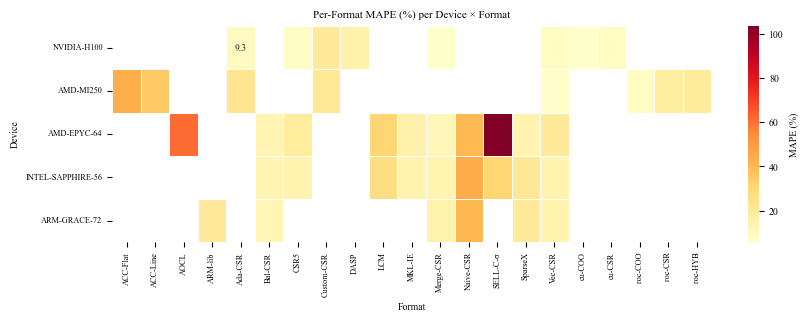

In [19]:
# Heatmap: MAPE per (device, format)
pivot_mape = results_df.groupby(['System','format_name'])['MAPE'].mean().reset_index()
pivot_mape = pivot_mape.pivot(index='System', columns='format_name', values='MAPE')
pivot_mape = pivot_mape.reindex(ranges_dev)

fig, ax = plt.subplots(figsize=(width*2.5, height*1.5))
sns.heatmap(pivot_mape, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'MAPE (%)'})
ax.set_title('Per-Format MAPE (%) per Device × Format', fontsize=8)
ax.set_xlabel('Format', fontsize=7)
ax.set_ylabel('Device', fontsize=7)
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig('./Plots/Validation_MAPE_heatmap.pdf', bbox_inches='tight')
plt.show()


In [20]:
# Print overall summary
print('\n' + '='*60)
print('OVERALL SUMMARY')
print('='*60)
overall_mape = results_df['MAPE'].mean()
overall_cv = results_df['CV'].mean()
overall_std = results_df['friend_std'].mean()
print(f'Overall MAPE:     {overall_mape:.2f}%')
print(f'Overall Mean CV:  {overall_cv:.2f}%')
print(f'Overall Mean Std: {overall_std:.2f} GFLOPs')
print()
print('Per-device MAPE:')
for dev in ranges_dev:
    dev_mape = results_df[results_df['System']==dev]['MAPE'].mean()
    dev_cv = results_df[results_df['System']==dev]['CV'].mean()
    print(f'  {dev:25s}  MAPE={dev_mape:6.2f}%  CV={dev_cv:6.2f}%')



OVERALL SUMMARY
Overall MAPE:     21.24%
Overall Mean CV:  7.11%
Overall Mean Std: 6.17 GFLOPs

Per-device MAPE:
  NVIDIA-H100                MAPE= 10.07%  CV=  4.55%
  AMD-MI250                  MAPE= 21.75%  CV=  7.36%
  AMD-EPYC-64                MAPE= 31.16%  CV=  7.59%
  INTEL-SAPPHIRE-56          MAPE= 20.69%  CV=  8.11%
  ARM-GRACE-72               MAPE= 20.23%  CV=  8.02%
